In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#reading the divided data, only the training part
d1 =pd.read_csv("data_divided/training_full.csv")
d2 = pd.read_csv("data_divided/validation_full.csv")

data = pd.concat([d1, d2])

print(data.info())
data.head()

<class 'pandas.DataFrame'>
Index: 16724 entries, 0 to 4180
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price_numeric   16724 non-null  float64
 1   Height          16724 non-null  float64
 2   Width           16724 non-null  float64
 3   Uniqueness      16724 non-null  str    
 4   gender_guessed  16724 non-null  str    
 5   gallery         16724 non-null  str    
 6   painting        16724 non-null  str    
 7   is_signed       16724 non-null  str    
 8   age             16724 non-null  float64
 9   years_selling   16724 non-null  float64
 10  location        16724 non-null  str    
 11  image_path      16724 non-null  str    
dtypes: float64(5), str(7)
memory usage: 2.7 MB
None


,price_numeric,Height,Width,Uniqueness,gender_guessed,gallery,painting,is_signed,age,years_selling,location,image_path
0,10673.0,64.6,62.6,Unique,unknown,gallery,other,signed,0.0,10.0,France,images_thesis\2324622_1_m.jpg
1,666.0,19.7,19.7,Unique,male,independent,other,signed,1.0,1.0,other,images_thesis\2246233_1_m.jpg
2,1275.0,45.7,35.0,Unique,male,gallery,acrylic,signed,20.0,5.0,France,images_thesis\1098924_1_m.jpg
3,972.0,18.1,15.0,Unique,male,gallery,acrylic,signed,25.0,1.0,Spain,images_thesis\2180624_1_m.jpg
4,4300.0,40.0,40.0,Unique,male,gallery,oil,not signed,3.0,3.0,United States,images_thesis\1842051_1_m.jpg


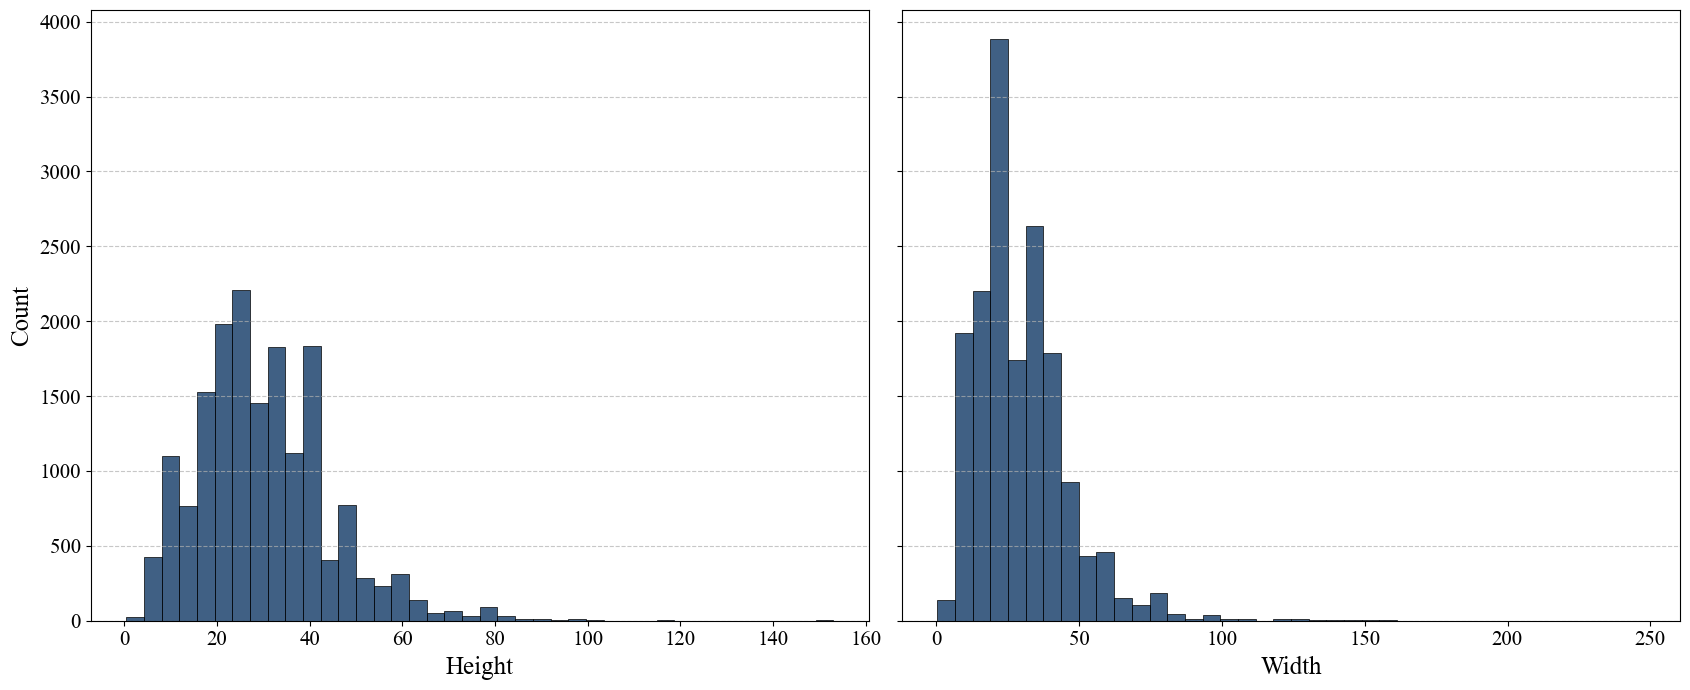

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Global font ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})

# ---- Font size variables ----
label_fontsize = 18     # axis label size
tick_fontsize = 15      # axis tick value size
figsize = (17, 7)       # figure size

# Create figure (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

dark_blue = "#002B5B"
bins = 40

# Height
sns.histplot(
    data=data, x="Height",
    bins=bins, color=dark_blue,
    edgecolor="black", linewidth=0.5,
    ax=axes[0]
)
axes[0].set_xlabel("Height", fontsize=label_fontsize)
axes[0].set_ylabel("Count", fontsize=label_fontsize)
axes[0].tick_params(axis='both', labelsize=tick_fontsize)
axes[0].grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].grid(axis='x', visible=False)

# Width
sns.histplot(
    data=data, x="Width",
    bins=bins, color=dark_blue,
    edgecolor="black", linewidth=0.5,
    ax=axes[1]
)
axes[1].set_xlabel("Width", fontsize=label_fontsize)
axes[1].set_ylabel("")
axes[1].tick_params(axis='both', labelsize=tick_fontsize)
axes[1].grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.7)
axes[1].grid(axis='x', visible=False)

# Get the maximum y value from both axes
max_y = max(ax.get_ylim()[1] for ax in axes)

# Set the same y-axis range for both plots
for ax in axes:
    ax.set_ylim(0, max_y)

plt.tight_layout()
plt.savefig("visuals/height_width_full_vs_cleaned.png", dpi=700, bbox_inches='tight')
plt.show()

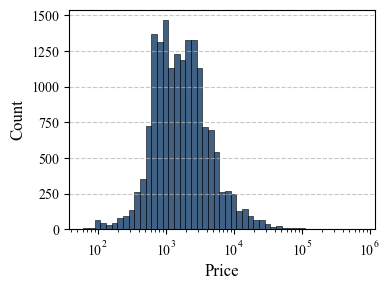

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- Global font ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})

# ---- Size variables ----
label_fontsize = 12     # axis label size
tick_fontsize = 10      # axis tick value size
figsize = (4, 3)        # figure size

dark_blue = "#002B5B"

price_full = data["price_numeric"]

bins = np.logspace(
    np.log10(price_full.min()),
    np.log10(price_full.max()),
    50
)

plt.figure(figsize=figsize)

sns.histplot(
    price_full,
    bins=bins,
    color=dark_blue,
    edgecolor="black",
    linewidth=0.4
)

plt.xscale("log")
plt.xlabel("Price", fontsize=label_fontsize)
plt.ylabel("Count", fontsize=label_fontsize)
plt.tick_params(axis='both', labelsize=tick_fontsize)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.savefig("visuals/price.png", dpi=700, bbox_inches='tight')
plt.show()

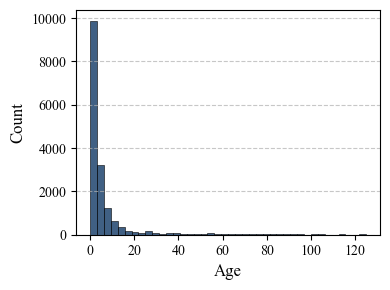

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Global font ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})

# ---- Size variables ----
label_fontsize = 12     # axis label size
tick_fontsize = 10      # axis tick value size
figsize = (4, 3)        # figure size

dark_blue = "#002B5B"
bins = 40

plt.figure(figsize=figsize)

# FULL only
sns.histplot(
    data=data,
    x="age",
    bins=bins,
    color=dark_blue,
    edgecolor="black",
    linewidth=0.4
)

plt.xlabel("Age", fontsize=label_fontsize)
plt.ylabel("Count", fontsize=label_fontsize)
plt.tick_params(axis='both', labelsize=tick_fontsize)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.savefig("visuals/age.png", dpi=700, bbox_inches='tight')
plt.show()

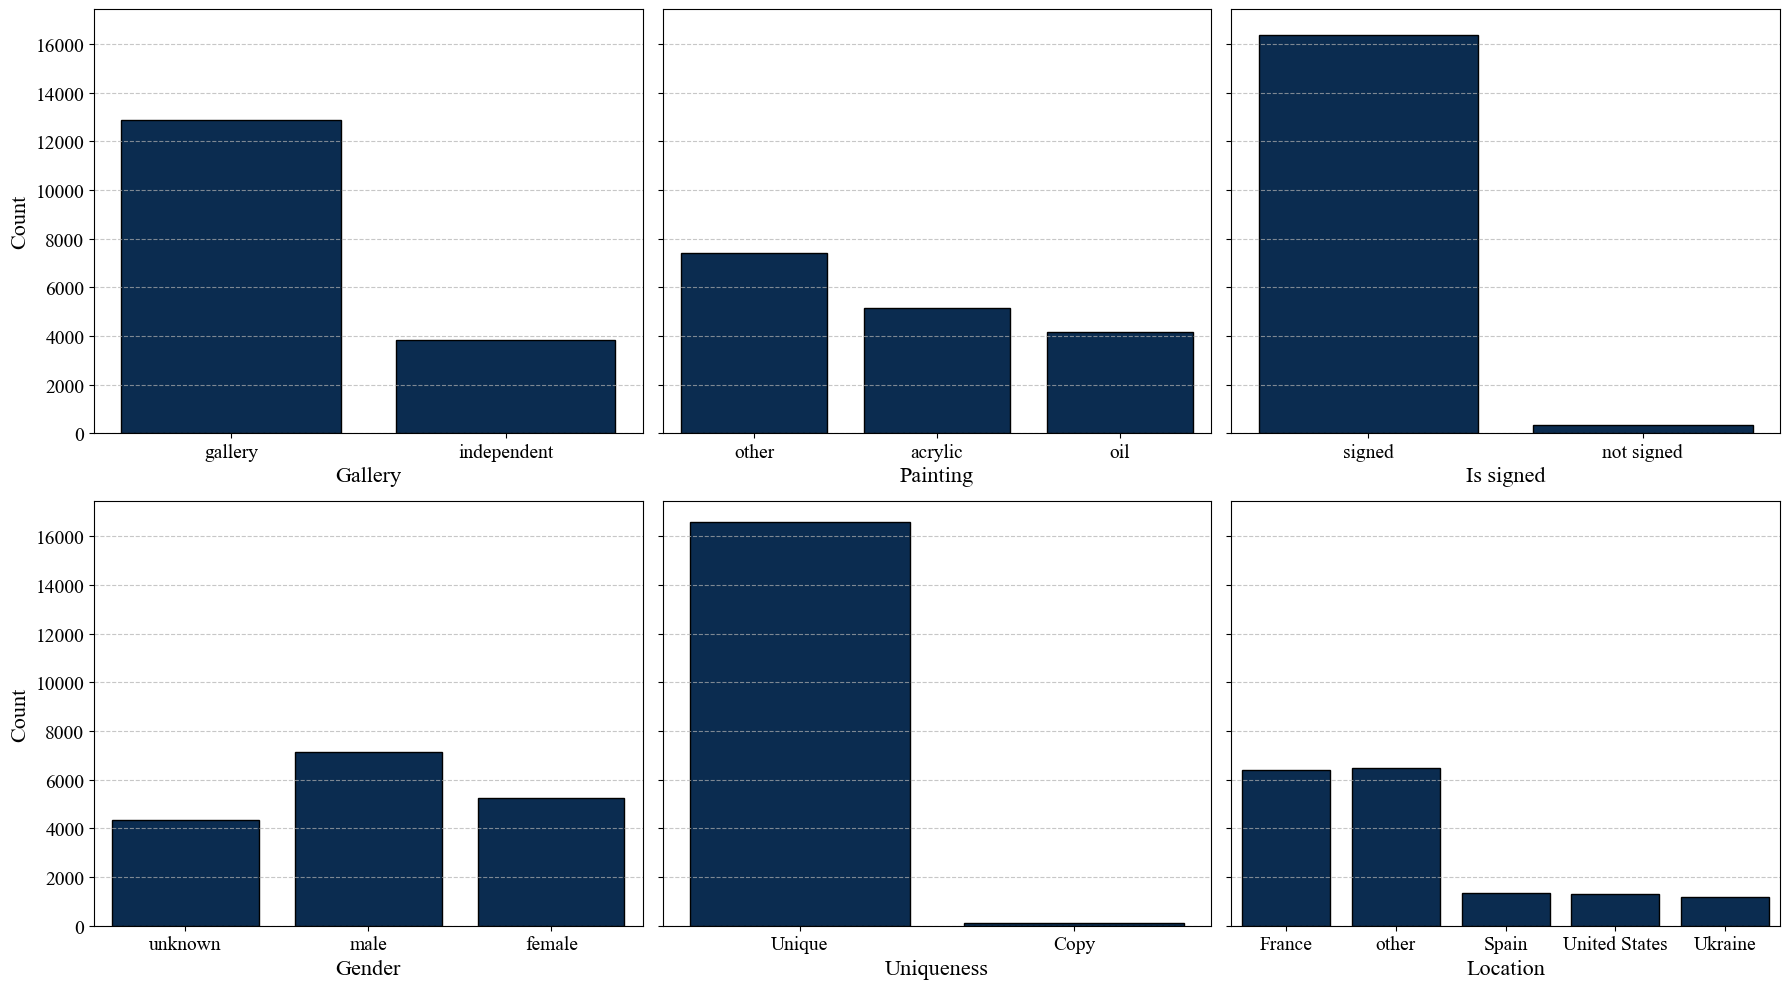

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Global font ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})

# ---- Size variables ----
label_fontsize = 16
tick_fontsize = 14
figsize = (18, 10)
font_color = "#000000"   # slightly lighter than black

fig, axes = plt.subplots(2, 3, figsize=figsize, sharey='row')

dark_blue = "#002B5B"

# Gallery
sns.countplot(data=data, x='gallery',
              color=dark_blue, edgecolor="black",
              ax=axes[0, 0])
axes[0, 0].set_xlabel("Gallery", fontsize=label_fontsize, color=font_color)
axes[0, 0].set_ylabel("Count", fontsize=label_fontsize, color=font_color)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0, 0].grid(axis='x', visible=False)

# Painting
sns.countplot(data=data, x='painting',
              color=dark_blue, edgecolor="black",
              ax=axes[0, 1])
axes[0, 1].set_xlabel("Painting", fontsize=label_fontsize, color=font_color)
axes[0, 1].set_ylabel("")
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)
axes[0, 1].grid(axis='x', visible=False)

# Is signed
sns.countplot(data=data, x='is_signed',
              color=dark_blue, edgecolor="black",
              ax=axes[0, 2])
axes[0, 2].set_xlabel("Is signed", fontsize=label_fontsize, color=font_color)
axes[0, 2].set_ylabel("")
axes[0, 2].grid(axis='y', linestyle='--', alpha=0.7)
axes[0, 2].grid(axis='x', visible=False)

# Gender
sns.countplot(data=data, x='gender_guessed',
              color=dark_blue, edgecolor="black",
              ax=axes[1, 0])
axes[1, 0].set_xlabel("Gender", fontsize=label_fontsize, color=font_color)
axes[1, 0].set_ylabel("Count", fontsize=label_fontsize, color=font_color)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)
axes[1, 0].grid(axis='x', visible=False)

# Uniqueness
sns.countplot(data=data, x='Uniqueness',
              color=dark_blue, edgecolor="black",
              ax=axes[1, 1])
axes[1, 1].set_xlabel("Uniqueness", fontsize=label_fontsize, color=font_color)
axes[1, 1].set_ylabel("")
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1, 1].grid(axis='x', visible=False)

# Location
sns.countplot(data=data, x='location',
              color=dark_blue, edgecolor="black",
              ax=axes[1, 2])
axes[1, 2].set_xlabel("Location", fontsize=label_fontsize, color=font_color)
axes[1, 2].set_ylabel("")
axes[1, 2].grid(axis='y', linestyle='--', alpha=0.7)
axes[1, 2].grid(axis='x', visible=False)

# Tick labels
for ax in axes.flatten():
    ax.tick_params(axis='both', labelsize=tick_fontsize, colors=font_color)

# Same y-axis across all plots
max_y = max(ax.get_ylim()[1] for ax in axes.flatten())
for ax in axes.flatten():
    ax.set_ylim(0, max_y)

plt.tight_layout()
plt.savefig("visuals/barplots_full_vs_cleaned.png", dpi=700, bbox_inches='tight')
plt.show()

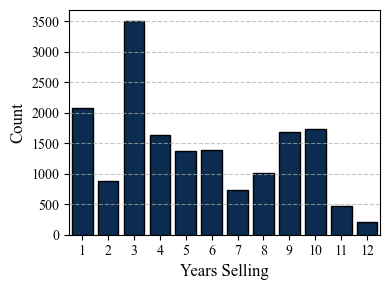

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Global font ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})

# ---- Size variables ----
label_fontsize = 12
tick_fontsize = 10
figsize = (4, 3)

plt.figure(figsize=figsize)

dark_blue = "#002B5B"

# Consistent order (only from full now)
years_order = sorted(data["years_selling"].dropna().unique())

# ================= FULL =================
sns.countplot(
    data=data,
    x="years_selling",
    order=years_order,
    color=dark_blue,
    edgecolor="black"
)

plt.xlabel("Years Selling", fontsize=label_fontsize)
plt.ylabel("Count", fontsize=label_fontsize)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)

# Format x labels as integers
plt.xticks(
    ticks=range(len(years_order)),
    labels=[int(x) for x in years_order]
)

# Tick formatting
plt.tick_params(axis='both', labelsize=tick_fontsize)

plt.tight_layout()
plt.savefig("visuals/years_selling_bar_full.png", dpi=300, bbox_inches='tight')
plt.show()

In [33]:
cat_cols = data.select_dtypes(include = 'str').drop(columns= "image_path").columns.to_list()
num_cols = data.select_dtypes(include = 'number').columns.to_list()

print(cat_cols)
print(num_cols)

['Uniqueness', 'gender_guessed', 'gallery', 'painting', 'is_signed', 'location']
['price_numeric', 'Height', 'Width', 'age', 'years_selling']


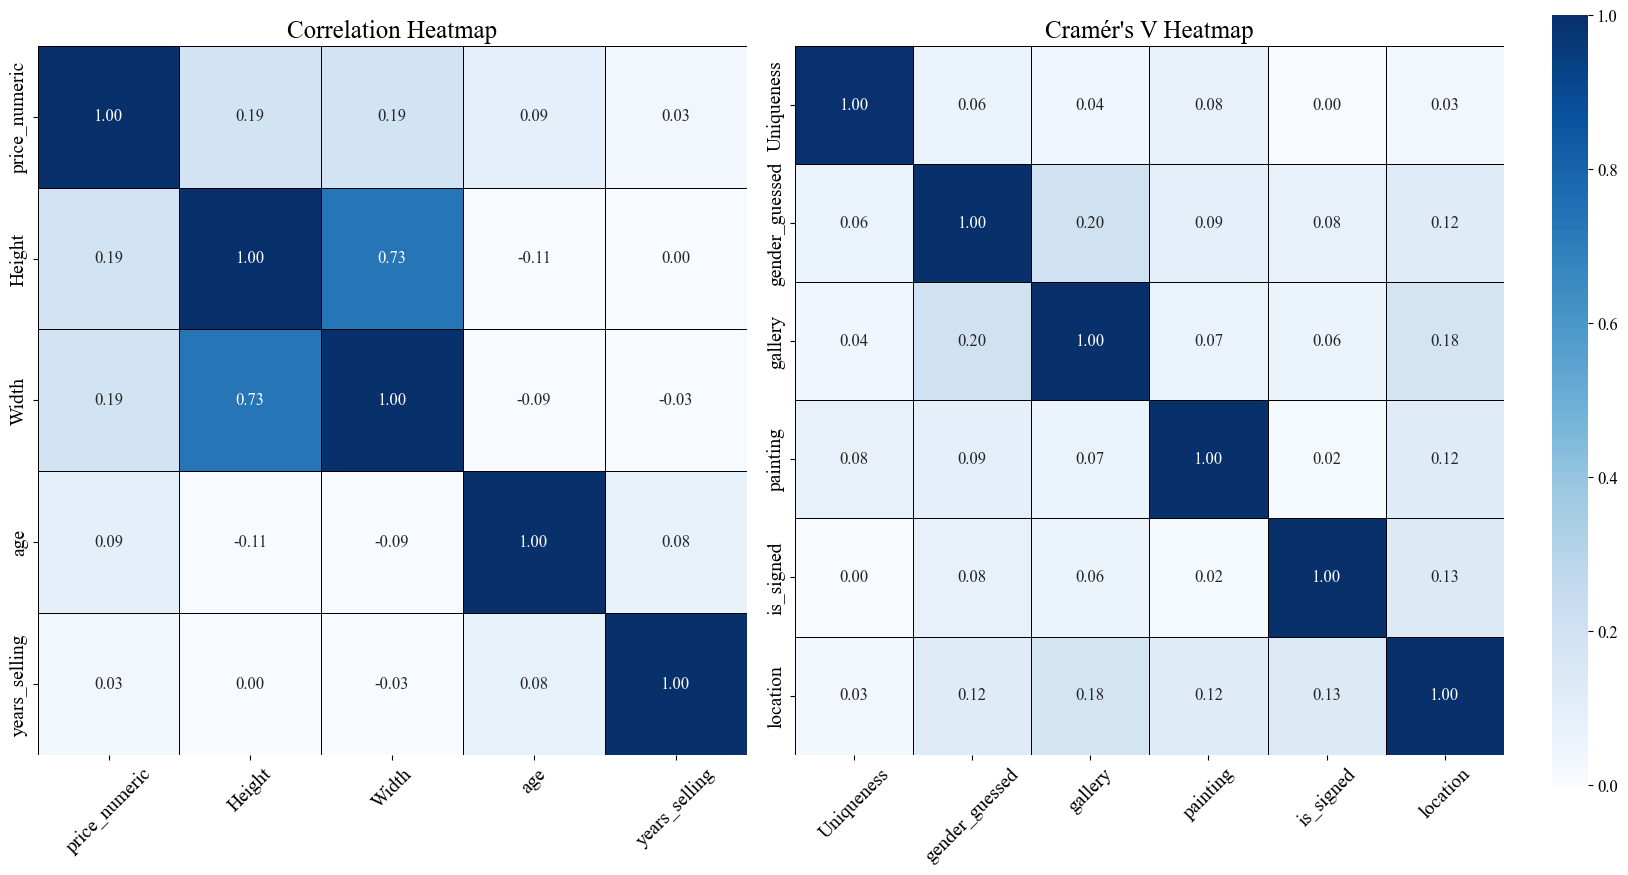

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Function: Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x.values, y.values)

    if confusion_matrix.empty:
        return np.nan

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    if n == 0:
        return np.nan

    r, k = confusion_matrix.shape
    phi2 = chi2 / n

    if n == 1:
        return np.nan

    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    if min(kcorr - 1, rcorr - 1) <= 0:
        return np.nan

    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))

# Matrices
corr_matrix = data[num_cols].corr()

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])

# Style
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})

# ---- Size variables ----
title_fontsize = 18
tick_fontsize = 14
annot_fontsize = 12
colorbar_tick_fontsize = 12
figsize = (20, 10)

# Layout: two same-sized heatmaps + one side colorbar
fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.10)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

vmin = 0
vmax = 1

# Correlation heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax,
    square=False,
    linewidths=0.5,
    linecolor="black",
    cbar=False,
    ax=ax1,
    annot_kws={"size": annot_fontsize}
)

# Cramér's V heatmap
sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax,
    square=False,
    linewidths=0.5,
    linecolor="black",
    cbar=True,
    cbar_ax=cax,
    ax=ax2,
    annot_kws={"size": annot_fontsize}
)

# Force same plot box shape
ax1.set_box_aspect(1)
ax2.set_box_aspect(1)

ax1.set_title("Correlation Heatmap", fontsize=title_fontsize)
ax2.set_title("Cramér's V Heatmap", fontsize=title_fontsize)

ax1.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
ax1.tick_params(axis='y', labelsize=tick_fontsize)

ax2.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
ax2.tick_params(axis='y', labelsize=tick_fontsize)

cax.tick_params(labelsize=colorbar_tick_fontsize)

plt.savefig("visuals/heatmaps.png", dpi=700, bbox_inches="tight")
plt.show()